# Part 2 — Decoder Training
## Neural Network Decoder for Distance-3 Surface Code

Both decoders are trained on data from the **same sampling run** (generated in notebook 01),
so the comparison is fair — same shots, same labels, different input representations.

| | Input | Labels | Width | Representation |
|---|---|---|---|---|
| **Part 1** | `detection_events` | `observable_flips` | 72 | XOR of consecutive syndrome rounds (processed) |
| **Part 2** | `raw_measurements` | `observable_flips` | 72 | Raw syndrome bits — no XOR applied (unprocessed) |

### Install
```bash
pip install torch scikit-learn matplotlib numpy
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import time, os, warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")

Device  : cuda
PyTorch : 2.10.0+cu128


---
## 1. Load Data

All three arrays come from `01_data_generation.ipynb` — one sampling run.

In [2]:
DATA_DIR = "data"

det  = np.load(f"{DATA_DIR}/detection_events.npy").astype(np.float32)  # Part 1 input
raw  = np.load(f"{DATA_DIR}/raw_measurements.npy").astype(np.float32)  # Part 2 input
obs  = np.load(f"{DATA_DIR}/observable_flips.npy").astype(np.float32).squeeze()  # shared labels

print("=== Data ===")
print(f"  detection_events : {det.shape}    (Part 1 input — XOR-processed syndromes)")
print(f"  raw_measurements : {raw.shape}    (Part 2 input — raw syndrome bits, no XOR)")
print(f"  observable_flips : {obs.shape}  (shared labels)")
print()
assert det.shape == raw.shape, "Shapes must match — both should be (N, 72)"
print(f"  Both inputs have the same shape {det.shape} — same information, different representation.")
print(f"  Logical error rate : {obs.mean():.4f}  ({int(obs.sum()):,} errors in {len(obs):,} shots)")
print()
print("The ONLY difference between Part 1 and Part 2 inputs:")
print("  detection_events[i,j] = raw[i,j] XOR raw[i, j - num_ancilla]   (Stim computes this)")
print("  raw_measurements[i,j] = the actual bit measured for ancilla j in round r")

=== Data ===
  detection_events : (100000, 72)    (Part 1 input — XOR-processed syndromes)
  raw_measurements : (100000, 72)    (Part 2 input — raw syndrome bits, no XOR)
  observable_flips : (100000,)  (shared labels)

  Both inputs have the same shape (100000, 72) — same information, different representation.
  Logical error rate : 0.0549  (5,487 errors in 100,000 shots)

The ONLY difference between Part 1 and Part 2 inputs:
  detection_events[i,j] = raw[i,j] XOR raw[i, j - num_ancilla]   (Stim computes this)
  raw_measurements[i,j] = the actual bit measured for ancilla j in round r


---
## 2. Train / Val / Test Split

Same indices for both parts — same shots in train/val/test for both decoders.

In [3]:
# Split indices once — apply to all three arrays
idx = np.arange(len(obs))
idx_tr, idx_tmp = train_test_split(idx, test_size=0.30, stratify=obs.astype(int), random_state=SEED)
idx_val, idx_te = train_test_split(idx_tmp, test_size=0.50, stratify=obs[idx_tmp].astype(int), random_state=SEED)

det_tr,  det_val,  det_te  = det[idx_tr],  det[idx_val],  det[idx_te]
raw_tr,  raw_val,  raw_te  = raw[idx_tr],  raw[idx_val],  raw[idx_te]
obs_tr,  obs_val,  obs_te  = obs[idx_tr],  obs[idx_val],  obs[idx_te]

print(f"Split  →  train: {len(idx_tr):,}  val: {len(idx_val):,}  test: {len(idx_te):,}")
print(f"Label error rates  →  train: {obs_tr.mean():.4f}  val: {obs_val.mean():.4f}  test: {obs_te.mean():.4f}")
print()
print("Same indices used for both Part 1 and Part 2 splits.")

trivial_ler = obs_te.mean()
print(f"\nTrivial decoder LER (always predict 0): {trivial_ler:.4f}  ({100*trivial_ler:.4f}%)")

Split  →  train: 70,000  val: 15,000  test: 15,000
Label error rates  →  train: 0.0549  val: 0.0549  test: 0.0549

Same indices used for both Part 1 and Part 2 splits.

Trivial decoder LER (always predict 0): 0.0549  (5.4867%)


---
## 3. Model & Training Infrastructure

In [4]:
class SurfaceCodeDecoder(nn.Module):
    def __init__(self, input_dim: int, hidden: list = [256, 128, 64], dropout: float = 0.3):
        super().__init__()
        layers = []
        in_dim = input_dim
        for i, h in enumerate(hidden):
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout if i < len(hidden) - 1 else 0.0),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def make_loader(X, y, batch_size=512, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(Xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        preds   = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == yb).sum().item()
        total   += len(yb)
        total_loss += loss.item() * len(yb)
    return total_loss / total, 1 - correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        logits  = model(Xb)
        loss    = criterion(logits, yb)
        preds   = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == yb).sum().item()
        total   += len(yb)
        total_loss += loss.item() * len(yb)
    return total_loss / total, 1 - correct / total


def train_decoder(X_tr, y_tr, X_val, y_val, input_dim,
                  hidden=[256, 128, 64], epochs=100, lr=1e-3,
                  batch_size=512, patience=12, label=""):
    model     = SurfaceCodeDecoder(input_dim, hidden).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    pos_weight = torch.tensor([(1 - y_tr.mean()) / y_tr.mean()]).to(DEVICE)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    tr_loader  = make_loader(X_tr,  y_tr,  batch_size)
    val_loader = make_loader(X_val, y_val, batch_size, shuffle=False)

    history = {'tr_loss': [], 'val_loss': [], 'tr_ler': [], 'val_ler': []}
    best_val_loss, best_epoch, best_state = np.inf, 0, None
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        tr_loss,  tr_ler  = train_epoch(model, tr_loader,  optimizer, criterion)
        val_loss, val_ler = eval_epoch(model,  val_loader, criterion)
        scheduler.step(val_loss)

        for k, v in zip(['tr_loss','val_loss','tr_ler','val_ler'],
                        [tr_loss, val_loss, tr_ler, val_ler]):
            history[k].append(v)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch    = epoch
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 10 == 0 or epoch == 1:
            print(f"  [{label}] Epoch {epoch:3d}  "
                  f"tr_loss={tr_loss:.4f}  val_loss={val_loss:.4f}  val_LER={val_ler:.5f}")

        if epoch - best_epoch >= patience:
            print(f"  [{label}] Early stop at epoch {epoch} (best={best_epoch})")
            break

    model.load_state_dict(best_state)
    elapsed = time.time() - t0
    print(f"  [{label}] Done in {elapsed:.1f}s | best epoch={best_epoch} | val_loss={best_val_loss:.5f}")
    return model, history


@torch.no_grad()
def predict(model, X, batch_size=1024):
    model.eval()
    dummy  = np.zeros(len(X), dtype=np.float32)
    loader = make_loader(X, dummy, batch_size, shuffle=False)
    preds  = []
    for Xb, _ in loader:
        logits = model(Xb.to(DEVICE))
        preds.append((torch.sigmoid(logits) > 0.5).cpu().numpy())
    return np.concatenate(preds)


def logical_error_rate(y_true, y_pred):
    return (y_true != y_pred).mean()


print("All helpers defined.")
demo = SurfaceCodeDecoder(72)
print(f"Decoder params (input=72): {sum(p.numel() for p in demo.parameters()):,}")

All helpers defined.
Decoder params (input=72): 60,801


---
## 4. Train Part 1 — Detection Events → Observable Flip

In [5]:
print("=" * 58)
print("PART 1 — Detection Events (72) → Observable Flip")
print("=" * 58)

model_p1, hist_p1 = train_decoder(
    det_tr, obs_tr, det_val, obs_val,
    input_dim=det_tr.shape[1],
    label="Part1",
)

pred_p1 = predict(model_p1, det_te)
ler_p1  = logical_error_rate(obs_te, pred_p1)
print(f"\n  Part 1 Test LER : {ler_p1:.5f}  ({100*ler_p1:.4f}%)")
print(f"  Trivial LER     : {trivial_ler:.5f}  ({100*trivial_ler:.4f}%)")
print(f"  Improvement     : {trivial_ler/ler_p1:.1f}x" if ler_p1 > 0 else "  Improvement : Perfect (0 errors)")

PART 1 — Detection Events (72) → Observable Flip


  [Part1] Epoch   1  tr_loss=0.5828  val_loss=0.3158  val_LER=0.08573
  [Part1] Epoch  10  tr_loss=0.0899  val_loss=0.1350  val_LER=0.01447
  [Part1] Epoch  20  tr_loss=0.0455  val_loss=0.1830  val_LER=0.00773
  [Part1] Early stop at epoch 20 (best=8)
  [Part1] Done in 20.9s | best epoch=8 | val_loss=0.12488

  Part 1 Test LER : 0.01447  (1.4467%)
  Trivial LER     : 0.05487  (5.4867%)
  Improvement     : 3.8x


---
## 5. Train Part 2 — Raw Measurements → Observable Flip

In [6]:
print("=" * 58)
print("PART 2 — Raw Measurements (72) → Observable Flip")
print("=" * 58)

model_p2, hist_p2 = train_decoder(
    raw_tr, obs_tr, raw_val, obs_val,
    input_dim=raw_tr.shape[1],
    label="Part2",
)

pred_p2 = predict(model_p2, raw_te)
ler_p2  = logical_error_rate(obs_te, pred_p2)
print(f"\n  Part 2 Test LER : {ler_p2:.5f}  ({100*ler_p2:.4f}%)")
print(f"  Trivial LER     : {trivial_ler:.5f}  ({100*trivial_ler:.4f}%)")
print(f"  Improvement     : {trivial_ler/ler_p2:.1f}x" if ler_p2 > 0 else "  Improvement : Perfect (0 errors)")

PART 2 — Raw Measurements (72) → Observable Flip
  [Part2] Epoch   1  tr_loss=0.5906  val_loss=0.4451  val_LER=0.07640
  [Part2] Epoch  10  tr_loss=0.3493  val_loss=0.3615  val_LER=0.03140
  [Part2] Epoch  20  tr_loss=0.3025  val_loss=0.3632  val_LER=0.02653
  [Part2] Early stop at epoch 23 (best=11)
  [Part2] Done in 24.0s | best epoch=11 | val_loss=0.35588

  Part 2 Test LER : 0.03660  (3.6600%)
  Trivial LER     : 0.05487  (5.4867%)
  Improvement     : 1.5x


---
## 6. Compare: Detection Events vs Raw Measurements

This is the core comparison the professor asked for.
Same shots, same labels — only the input representation differs.

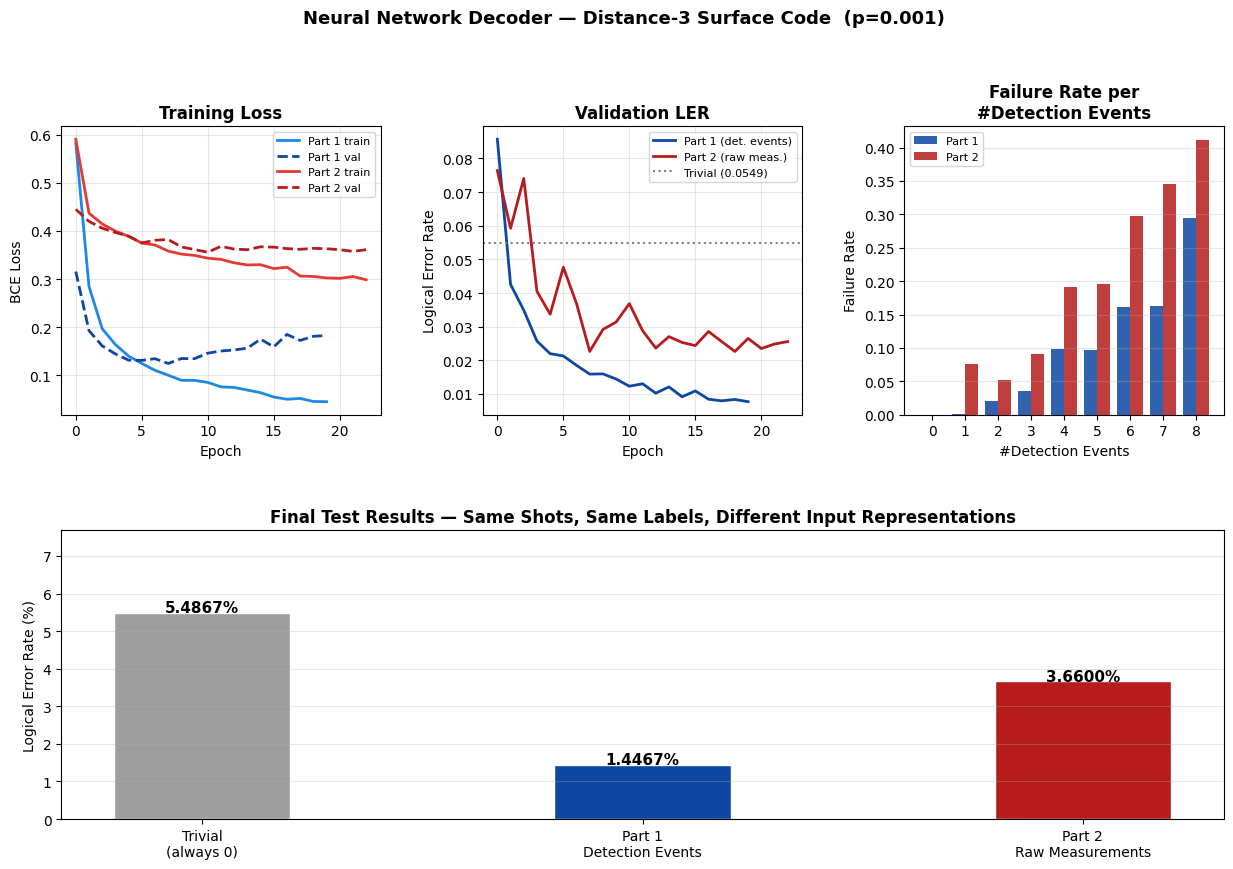

Saved → decoder_comparison.png


In [7]:
fig = plt.figure(figsize=(15, 9))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.32)

C1_TR, C1_VAL = '#1E88E5', '#0D47A1'
C2_TR, C2_VAL = '#E53935', '#B71C1C'

# ── Loss curves ───────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.plot(hist_p1['tr_loss'],  color=C1_TR,  lw=2, label='Part 1 train')
ax.plot(hist_p1['val_loss'], color=C1_VAL, lw=2, label='Part 1 val', ls='--')
ax.plot(hist_p2['tr_loss'],  color=C2_TR,  lw=2, label='Part 2 train')
ax.plot(hist_p2['val_loss'], color=C2_VAL, lw=2, label='Part 2 val', ls='--')
ax.set_title('Training Loss', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── LER curves ────────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
ax.plot(hist_p1['val_ler'], color=C1_VAL, lw=2, label='Part 1 (det. events)')
ax.plot(hist_p2['val_ler'], color=C2_VAL, lw=2, label='Part 2 (raw meas.)')
ax.axhline(trivial_ler, color='grey', lw=1.5, ls=':', label=f'Trivial ({trivial_ler:.4f})')
ax.set_title('Validation LER', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Logical Error Rate')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Failure analysis: Part 1 failures by #events ──────────────────────────────
ax = fig.add_subplot(gs[0, 2])
events_te = det_te.sum(axis=1).astype(int)
fail_p1   = (pred_p1 != obs_te)
fail_p2   = (pred_p2 != obs_te)
ks, r1s, r2s = [], [], []
for k in range(0, 9):
    m = events_te == k
    if m.sum() < 10: continue
    ks.append(k)
    r1s.append(fail_p1[m].mean())
    r2s.append(fail_p2[m].mean())
x = np.arange(len(ks))
ax.bar(x - 0.2, r1s, 0.4, label='Part 1', color=C1_VAL, alpha=0.85)
ax.bar(x + 0.2, r2s, 0.4, label='Part 2', color=C2_VAL, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([str(k) for k in ks])
ax.set_xlabel('#Detection Events'); ax.set_ylabel('Failure Rate')
ax.set_title('Failure Rate per\n#Detection Events', fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# ── Bar chart final results ────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, :])
methods = ['Trivial\n(always 0)',
           'Part 1\nDetection Events',
           'Part 2\nRaw Measurements']
lers   = [trivial_ler, ler_p1, ler_p2]
colors = ['#9E9E9E', C1_VAL, C2_VAL]
bars   = ax.bar(methods, [l * 100 for l in lers], color=colors, edgecolor='white', width=0.4)
for bar, ler in zip(bars, lers):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{100*ler:.4f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Logical Error Rate (%)')
ax.set_title('Final Test Results — Same Shots, Same Labels, Different Input Representations',
             fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, trivial_ler * 100 * 1.4)

fig.suptitle('Neural Network Decoder — Distance-3 Surface Code  (p=0.001)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('decoder_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → decoder_comparison.png")

---
## 7. Results Table & Classification Reports

In [8]:
print("=" * 62)
print("FINAL RESULTS  (test set, same shots & labels for both parts)")
print("=" * 62)
rows = [
    ("Trivial (always 0)",         trivial_ler, "-"),
    ("Part 1 — Detection Events",  ler_p1,      f"{trivial_ler/ler_p1:.1f}x" if ler_p1 > 0 else "∞"),
    ("Part 2 — Raw Measurements",  ler_p2,      f"{trivial_ler/ler_p2:.1f}x" if ler_p2 > 0 else "∞"),
]
print(f"  {'Method':<30} {'LER':>10}  {'vs Trivial':>12}")
print("  " + "-" * 56)
for name, ler, vs in rows:
    print(f"  {name:<30} {100*ler:>9.4f}%  {vs:>12}")

print()
print("Key: Both decoders receive 72 inputs from the same shots.")
print("  Part 1: XOR-processed detection events (Stim does the XOR).")
print("  Part 2: raw syndrome bits — network must learn the XOR structure itself.")
print("  Higher LER for Part 2 is the expected and meaningful result.")

print()
print("=== Classification Report — Part 1 (Detection Events) ===")
print(classification_report(obs_te.astype(int), pred_p1.astype(int),
                             target_names=['No Error', 'Logical Error']))

print("=== Classification Report — Part 2 (Raw Measurements) ===")
print(classification_report(obs_te.astype(int), pred_p2.astype(int),
                             target_names=['No Error', 'Logical Error']))

FINAL RESULTS  (test set, same shots & labels for both parts)
  Method                                LER    vs Trivial
  --------------------------------------------------------
  Trivial (always 0)                5.4867%             -
  Part 1 — Detection Events         1.4467%          3.8x
  Part 2 — Raw Measurements         3.6600%          1.5x

Key: Both decoders receive 72 inputs from the same shots.
  Part 1: XOR-processed detection events (Stim does the XOR).
  Part 2: raw syndrome bits — network must learn the XOR structure itself.
  Higher LER for Part 2 is the expected and meaningful result.

=== Classification Report — Part 1 (Detection Events) ===
               precision    recall  f1-score   support

     No Error       1.00      0.99      0.99     14177
Logical Error       0.81      0.97      0.88       823

     accuracy                           0.99     15000
    macro avg       0.90      0.98      0.94     15000
 weighted avg       0.99      0.99      0.99     150

---
## 8. Save Models

In [9]:
os.makedirs("models", exist_ok=True)

for tag, model, ler, idim, hist in [
    ("part1", model_p1, ler_p1, det_tr.shape[1], hist_p1),
    ("part2", model_p2, ler_p2, raw_tr.shape[1], hist_p2),
]:
    torch.save({
        'model_state': model.state_dict(),
        'input_dim':   idim,
        'hidden':      [256, 128, 64],
        'test_ler':    float(ler),
        'history':     hist,
    }, f"models/decoder_{tag}.pt")
    print(f"  Saved models/decoder_{tag}.pt  (test_ler={ler:.5f})")

  Saved models/decoder_part1.pt  (test_ler=0.01447)
  Saved models/decoder_part2.pt  (test_ler=0.03660)
